In [1]:
!python.exe -m pip install -q --upgrade pip

In [2]:
!pip install -q networkx scipy

In [3]:
!pip install -q pandoc

In [4]:
!pip install -q pyvis

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scipy.sparse as sp
import time
from pyvis.network import Network
import IPython
from IPython.display import IFrame
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


In [2]:
G=nx.read_weighted_edgelist('Dublin.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

In [3]:
!pip install -q ipysigma

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ipysigma import Sigma
from IPython.display import IFrame

def visualize_graph(graph, p=None, title='Probability of being infected', mode=0):
    # 1. Prepare Node Attributes
    node_colors = {}
    label_sizes = {}
    
    for i, node in enumerate(graph.nodes):
        graph.nodes[node]['label'] = str(node)
        # Create a mapping for label sizes to avoid the TypeError
        label_sizes[node] = 12 
        
        if p is not None:
            cmap = plt.get_cmap('viridis')
            norm = mcolors.Normalize(vmin=min(p), vmax=max(p))
            color_hex = mcolors.to_hex(cmap(norm(p[i])))
            node_colors[node] = color_hex

    # 2. Legend/Colorbar (Matplotlib)
    if p is not None:
        fig, ax = plt.subplots(figsize=(6, 1))
        if mode == 0:
            sm = plt.cm.ScalarMappable(cmap=plt.get_cmap('viridis'), norm=mcolors.Normalize(vmin=min(p), vmax=max(p)))
            fig.colorbar(sm, cax=ax, orientation='horizontal', label=title)
        else:
            cmap = plt.get_cmap('viridis')
            patch = plt.Rectangle((0, 0), 1, 1, fc=mcolors.to_hex(cmap(1.0)))
            ax.legend([patch], ["Dominating Set"], loc='center', frameon=False)
            ax.axis('off')
        plt.show()

    # 3. Configure Sigma Visualization
    viz = Sigma(
        graph,
        node_label="label",
        node_label_size=label_sizes,  # Now passing a mapping/dict
        node_color=node_colors if p is not None else None,
        node_size=graph.degree,
        start_layout=True,
        edge_color="#e0e0e0",
        height=600
    )

    # 4. Save and Display
    output_file = "network_viz.html"
    viz.to_html(output_file)
    
    return IFrame(src=f'./{output_file}', width='100%', height='650px')


In [13]:

visualize_graph(G)

## SIR

my_graph.html


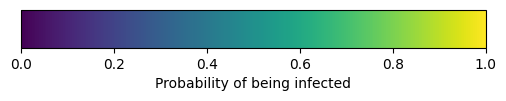

In [9]:
##SIR
def epi_step_SIR(A, I, S,R, n, gamma, beta):
    I_ = I
    S_ = S
    R_ = R
    for i in range(n):
        M=1
        f,f1,v = sp.find(A[:,i])
        for j in f1:
            M*=(1-I[j]*beta)
        S_[i] = S[i]*M
        I_[i]=S[i]*(1-M)+I[i]*(1-gamma)
        R_[i]= -(S_[i]+I_[i])
    return S_, I_, R_

def trial_SIR(A, gamma, beta, m, S_init, R_init, I_init):
    t = [0]*m
    n = len(A)
    S = S_init
    R = R_init
    I = I_init
    for i in range(m):
        t[i] = [sum(S), sum(R), sum(I)]
        S, I, R  = epi_step_SIR(A, I, S,R, n, gamma, beta)
        R = 1-S-I
    return t, S,I,R

m=120
gamma=0.01
beta=0.5
S = np.ones(n)
R = np.zeros(n)
I = np.zeros(n)
I[0]=1
S[0]=0

visualize_graph(G, I)


1.0938599109649658 seconds


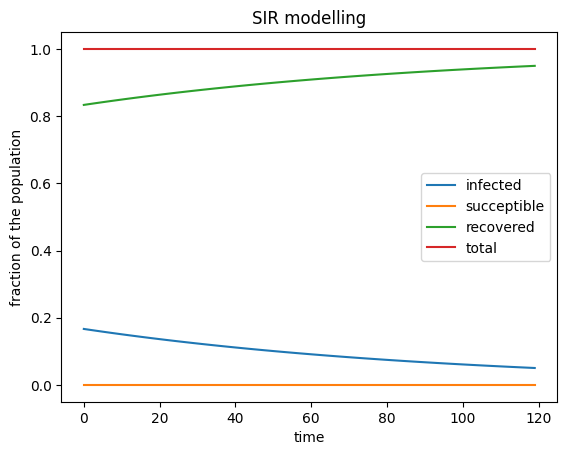

In [11]:
start_time = time.time()
t,S,I,R = trial_SIR(A, gamma, beta, m, S, R, I)
t = np.array(t)
print(time.time() - start_time, "seconds")

plt.plot(list(range(m)), t[:,2]/n, label="infected")
plt.plot(list(range(m)), t[:,0]/n, label="succeptible")
plt.plot(list(range(m)), t[:,1]/n, label = "recovered")
plt.plot(list(range(m)), (t[:,0]+t[:,1]+t[:,2])/n, label="total")
plt.title("SIR modelling")
plt.xlabel("time")
plt.ylabel("fraction of the population")
plt.legend()

my_graph.html


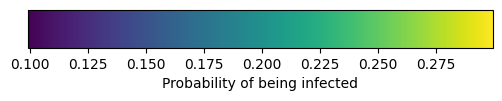

In [11]:
visualize_graph(G, I)

### SIRI

my_graph.html


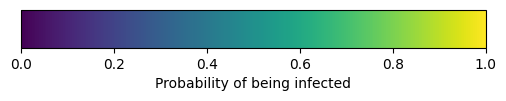

In [12]:
##SIRI
def epi_step_SIRI(A, I, S,R, n, gamma, beta, epsilon):
    I_ = I
    S_ = S
    R_ = R
    for i in range(n):
        M=1
        N=1
        f,f1,v = sp.find(A[:,i])
        for j in f1:
            M*=(1-I[j]*beta)
            N*=(1-I[j]*epsilon)
            
        S_[i] = S[i]*M
        I_[i]=S[i]*(1-M)+I[i]*(1-gamma) + R[i]*(1-N)
    R_= 1-S_-I_
    return S_, I_, R_

def trial_SIRI(A, gamma, beta,epsilon, m, S_init, R_init, I_init):
    t = [0]*m
    n = len(A)
    S = S_init
    R = R_init
    I = I_init
    for i in range(m):
        t[i] = [sum(S), sum(R), sum(I)]
        S, I, R  = epi_step_SIRI(A, I, S,R, n, gamma, beta, epsilon)
    return t, S,I,R

m=60
gamma=0.15
beta=0.25
epsilon = 0.2
S = np.ones(n)
R = np.zeros(n)
I = np.zeros(n)
I[0]=1
S[0]=0

visualize_graph(G,I)

0.47467827796936035 seconds


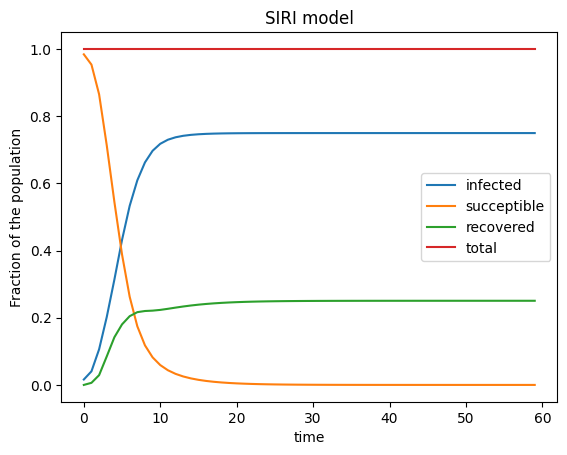

In [13]:
start_time = time.time()
t,S,I,R = trial_SIRI(A, gamma, beta,epsilon, m, S, R, I)
t = np.array(t)
print(time.time() - start_time, "seconds")

plt.plot(list(range(m)), t[:,2]/n, label="infected")
plt.plot(list(range(m)), t[:,0]/n, label="succeptible")
plt.plot(list(range(m)), t[:,1]/n, label = "recovered")
plt.plot(list(range(m)), (t[:,0]+t[:,1]+t[:,2])/n, label="total")
plt.xlabel("time")
plt.ylabel("Fraction of the population")
plt.title("SIRI model")
plt.legend()

my_graph.html


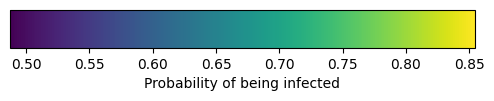

In [14]:
visualize_graph(G,I)

## Vaccination using dominating set(SIRI)

In [15]:
import random

In [16]:
from networkx.algorithms.dominating import dominating_set

### dominating set

In [17]:
dominatingSet = list(dominating_set(G))
print("the dominating set")
print(dominatingSet)
print("size", len(dominatingSet))

the dominating set
[0, 2, 4, 5, 7, 11, 12, 14, 16, 19, 21, 27, 28, 29, 31, 32, 34, 37, 41, 48, 50, 51, 54, 57, 58]
size 25


my_graph.html


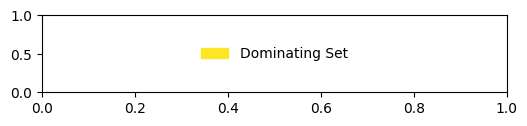

In [18]:
p = [0] *n
for node in dominatingSet:
    p[node]=1
visualize_graph(G, p, title="Dominating Set", mode=1)

In [19]:
##SIRI
def epi_step_SIRI_V(A, I, S,R, n,vaccinated, gamma, beta, epsilon, b ,g, e, hn=None, mode = "SIRI"):
    ## b: being contaminated while vaccinated
    ## g: recovering while vaccinated
    ## e: being recontaminated while recovered and vaccinated
    #h: chance of contaminating someone, while being infected and vaccinated
    I_ = I
    S_ = S
    R_ = R
    for i in range(n):
        M=1
        N=1
        f,f1,v = sp.find(A[:,i])
        beta_ = beta if not vaccinated[i] else b
        epsilon_ = epsilon if not vaccinated[i] else e
        h_ = epsilon_ if hn is None else hn
        gamma_ = gamma if not vaccinated[i] else g
        h = beta_ if hn is None else hn
        
        for j in f1:
            beta_ = beta_ if not vaccinated[j] else h
            epsilon_ = epsilon_ if not vaccinated[j] else h_
            M*=(1-I[j]*beta_)
            N*=(1-I[j]*epsilon_)
            
        S_[i] = S[i]*M
        I_[i]=S[i]*(1-M)+I[i]*(1-gamma_) + R[i]*(1-N) if mode == "SIRI" else 1-S[i]
    R_= 1-S_-I_
    return S_, I_, R_

def trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b, g, e,h, m, S_init, R_init, I_init, mode = "SIRI"):
    t = [0]*m
    n = len(A)
    S = S_init
    R = R_init
    I = I_init
    for i in range(m):
        t[i] = [sum(S), sum(R), sum(I)]
        S, I, R  = epi_step_SIRI_V(A, I, S,R, n, vaccinated, gamma, beta, epsilon, b,g ,e, h, mode = mode)
    return t, S,I,R

my_graph.html


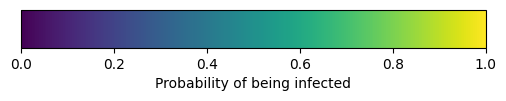

In [20]:
m_0=3 #time before the vaccination
gamma=0.15
beta=0.25
epsilon = 0.15

##perfect vaccine
b = 0 #rate of infection when the individual is vaccinated
g = 1 #rate of moving from infected to recovered when vaccinated.
e = 0 #rate of moving from recovered to infected when vaccinated
h = None
mode = "SIRI"
"""
##hiv vaccine
b = 1 #rate of infection when the succeptible individual is vaccinated
g = 0.0 #rate of moving from infected to recovered when vaccinated.
e = 0 #rate of moving from recovered to infected when vaccinated
h = 0.01 #chance of contaminating someone, while being infected and vaccinated
beta=0.25
epsilon =0.25
gamma = 0.0
mode = "SI"
"""

S = np.ones(n)
R = np.zeros(n)
I = np.zeros(n)
vaccinated = [False]*n #initially noone is vaccinated
I[0]=1 #one infected at the beginning
S[0]=0 
visualize_graph(G,I)

In [21]:
t,S,I,R = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h ,m_0,S, R, I, mode)
t = np.array(t)
x_0 = list(range(m_0))

my_graph.html


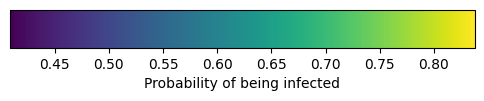

In [22]:
m_1=20 #simulation time after the vaccination
## simulation if we donot vaccinate
t1, S1, I1, R1 = t.copy(), S.copy(), I.copy(), R.copy()
t1, S1, I1, R1 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h, m_1, S1, R1, I1, mode)
idx = list(dominating_set(G))
t1 = np.array(t1)
t1 = np.vstack([t.copy(),t1])

visualize_graph(G,I1)


In [23]:

#simulation if we vaccinate individuals in the dominating set
for j in dominatingSet:#vaccinating everyIndividual in the dominating set
    vaccinated[j]=True
#start_time = time.time()
t2,S,I2,R2 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e,h, m_1, S.copy(), R.copy(), I.copy(),mode)
t2 = np.array(t2)
t2 = np.vstack([t.copy(),t2])
#print(time.time() - start_time, "seconds")

my_graph.html


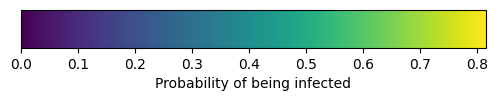

In [24]:
visualize_graph(G,I2)

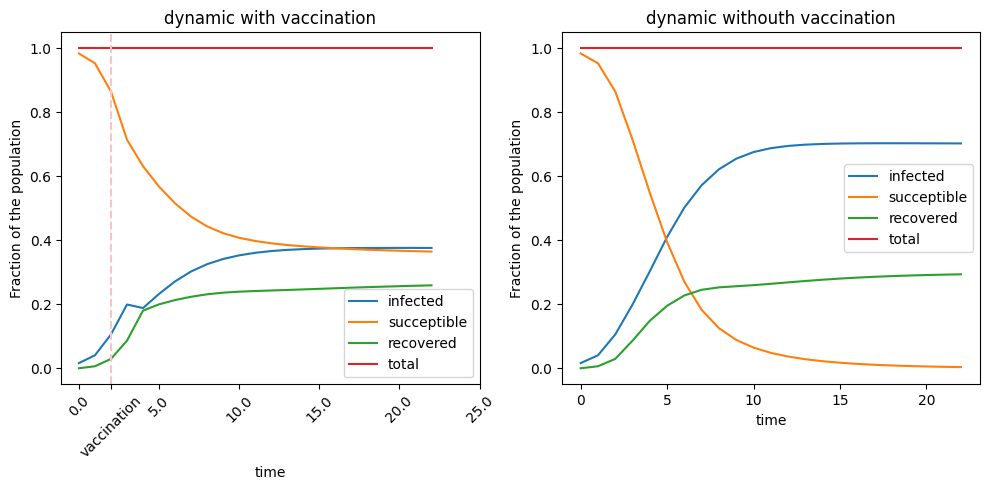

In [25]:
#ploting the results
x = x_0+list(range(m_0, m_0+m_1))
fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].plot(x, t2[:,2]/n, label="infected")
axs[0].plot(x, t2[:,0]/n, label="succeptible")
axs[0].plot(x, t2[:,1]/n, label = "recovered")
axs[0].plot(x, (t2[:,0]+t2[:,1]+t2[:,2])/n, label="total")
axs[0].set_title("dynamic with vaccination")
axs[0].axvline(m_0-1, color="pink", linestyle="--")
ticks = list(axs[0].get_xticks()) + [m_0-1]
ticks = [t for t in ticks if t >=0]
labels = [str(t) for t in ticks[:-1]] + ['vaccination']
axs[0].set_xticks(ticks, labels, rotation=45)
axs[0].legend(loc = "best")
axs[0].set_xlabel("time")
axs[0].set_ylabel("Fraction of the population")

axs[1].plot(x, t1[:,2]/n, label="infected")
axs[1].plot(x, t1[:,0]/n, label="succeptible")
axs[1].plot(x, t1[:,1]/n, label = "recovered")
axs[1].plot(x, (t1[:,0]+t1[:,1]+t1[:,2])/n, label="total")
axs[1].set_title("dynamic withouth vaccination")
axs[1].legend(loc = "best")
axs[1].set_xlabel("time")
axs[1].set_ylabel("Fraction of the population")
plt.tight_layout()

## Vaccination using Dominating Set on SI model

my_graph.html


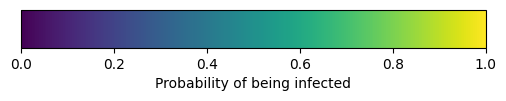

In [26]:
m_0=3 #time before the vaccination
gamma=0.15
beta=0.25
epsilon = 0.15

##hiv vaccine
b = 1 #rate of infection when the succeptible individual is vaccinated
g = 0.0 #rate of moving from infected to recovered when vaccinated.
e = 0 #rate of moving from recovered to infected when vaccinated
h = 0.01 #chance of contaminating someone, while being infected and vaccinated
beta=0.25
epsilon =0.25
gamma = 0.0
mode = "SI"

S = np.ones(n)
R = np.zeros(n)
I = np.zeros(n)
vaccinated = [False]*n #initially noone is vaccinated
I[0]=1 #one infected at the beginning
S[0]=0 
visualize_graph(G,I)

In [27]:
t,S,I,R = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h ,m_0,S, R, I, mode)
t = np.array(t)
x_0 = list(range(m_0))

my_graph.html


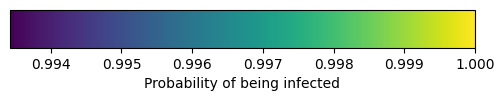

In [28]:
m_1=20 #simulation time after the vaccination
## simulation if we donot vaccinate
t1, S1, I1, R1 = t.copy(), S.copy(), I.copy(), R.copy()
t1, S1, I1, R1 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h, m_1, S1, R1, I1, mode)
idx = list(dominating_set(G))
t1 = np.array(t1)
t1 = np.vstack([t.copy(),t1])

visualize_graph(G,I1)


my_graph.html


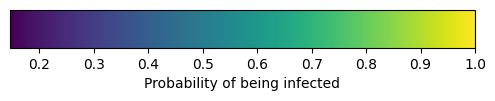

In [29]:

#simulation if we vaccinate individuals in the dominating set
for j in dominatingSet:#vaccinating everyIndividual in the dominating set
    vaccinated[j]=True
#start_time = time.time()
t2,S,I2,R2 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e,h, m_1, S.copy(), R.copy(), I.copy(),mode)
t2 = np.array(t2)
t2 = np.vstack([t.copy(),t2])
#print(time.time() - start_time, "seconds")
visualize_graph(G,I2)

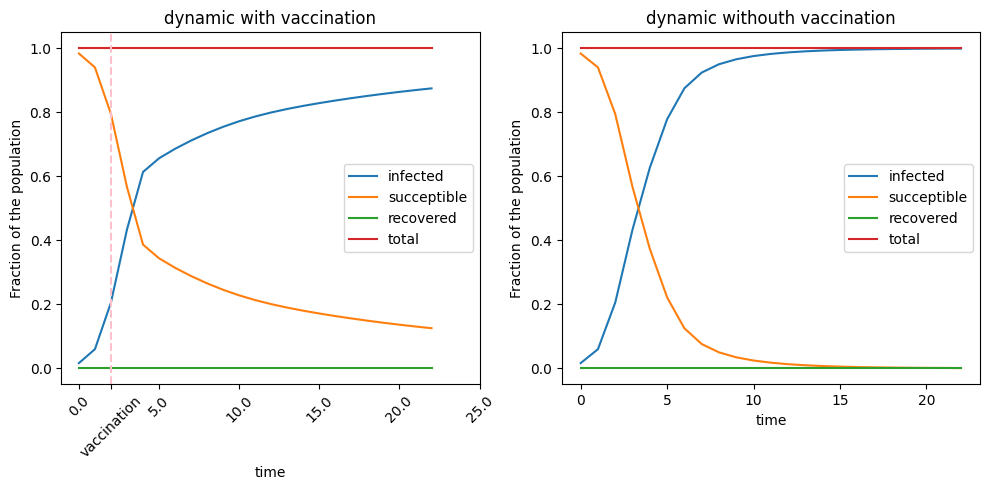

In [30]:
#ploting the results
x = x_0+list(range(m_0, m_0+m_1))
fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].plot(x, t2[:,2]/n, label="infected")
axs[0].plot(x, t2[:,0]/n, label="succeptible")
axs[0].plot(x, t2[:,1]/n, label = "recovered")
axs[0].plot(x, (t2[:,0]+t2[:,1]+t2[:,2])/n, label="total")
axs[0].set_title("dynamic with vaccination")
axs[0].axvline(m_0-1, color="pink", linestyle="--")
ticks = list(axs[0].get_xticks()) + [m_0-1]
ticks = [t for t in ticks if t >=0]
labels = [str(t) for t in ticks[:-1]] + ['vaccination']
axs[0].set_xticks(ticks, labels, rotation=45)
axs[0].legend(loc = "best")
axs[0].set_xlabel("time")
axs[0].set_ylabel("Fraction of the population")

axs[1].plot(x, t1[:,2]/n, label="infected")
axs[1].plot(x, t1[:,0]/n, label="succeptible")
axs[1].plot(x, t1[:,1]/n, label = "recovered")
axs[1].plot(x, (t1[:,0]+t1[:,1]+t1[:,2])/n, label="total")
axs[1].set_title("dynamic withouth vaccination")
axs[1].legend(loc = "best")
axs[1].set_xlabel("time")
axs[1].set_ylabel("Fraction of the population")
plt.tight_layout()

## SIR Model with vaccination

my_graph.html


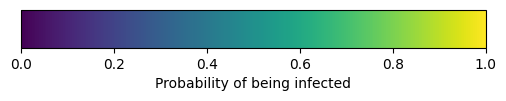

In [31]:
m_0=3 #time before the vaccination
gamma=0.15
beta=0.25
epsilon = 0.0

b = 0 #rate of infection when the individual is vaccinated
g = 1 #rate of moving from infected to recovered when vaccinated.
e = 0 #rate of moving from recovered to infected when vaccinated
h = None
mode = "SIRI"

S = np.ones(n)
R = np.zeros(n)
I = np.zeros(n)
vaccinated = [False]*n #initially noone is vaccinated
I[0]=1 #one infected at the beginning
S[0]=0 
visualize_graph(G,I)

In [32]:
t,S,I,R = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h ,m_0,S, R, I, mode)
t = np.array(t)
x_0 = list(range(m_0))

my_graph.html


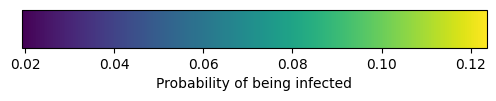

In [33]:
m_1=20 #simulation time after the vaccination
## simulation if we donot vaccinate
t1, S1, I1, R1 = t.copy(), S.copy(), I.copy(), R.copy()
t1, S1, I1, R1 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e, h, m_1, S1, R1, I1, mode)
idx = list(dominating_set(G))
t1 = np.array(t1)
t1 = np.vstack([t.copy(),t1])

visualize_graph(G,I1)


my_graph.html


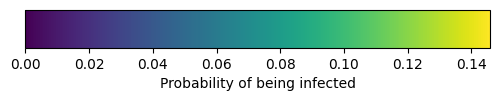

In [34]:

#simulation if we vaccinate individuals in the dominating set
for j in dominatingSet:#vaccinating everyIndividual in the dominating set
    vaccinated[j]=True
#start_time = time.time()
t2,S,I2,R2 = trial_SIRI_V(A,vaccinated, gamma, beta,epsilon,b,g,e,h, m_1, S.copy(), R.copy(), I.copy(),mode)
t2 = np.array(t2)
t2 = np.vstack([t.copy(),t2])
#print(time.time() - start_time, "seconds")
visualize_graph(G,I2)

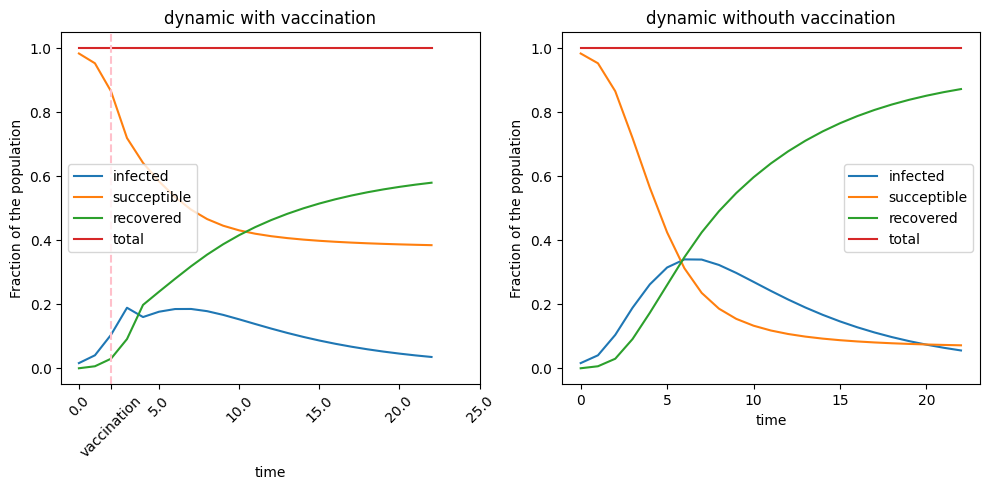

In [35]:
#ploting the results
x = x_0+list(range(m_0, m_0+m_1))
fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].plot(x, t2[:,2]/n, label="infected")
axs[0].plot(x, t2[:,0]/n, label="succeptible")
axs[0].plot(x, t2[:,1]/n, label = "recovered")
axs[0].plot(x, (t2[:,0]+t2[:,1]+t2[:,2])/n, label="total")
axs[0].set_title("dynamic with vaccination")
axs[0].axvline(m_0-1, color="pink", linestyle="--")
ticks = list(axs[0].get_xticks()) + [m_0-1]
ticks = [t for t in ticks if t >=0]
labels = [str(t) for t in ticks[:-1]] + ['vaccination']
axs[0].set_xticks(ticks, labels, rotation=45)
axs[0].legend(loc = "best")
axs[0].set_xlabel("time")
axs[0].set_ylabel("Fraction of the population")

axs[1].plot(x, t1[:,2]/n, label="infected")
axs[1].plot(x, t1[:,0]/n, label="succeptible")
axs[1].plot(x, t1[:,1]/n, label = "recovered")
axs[1].plot(x, (t1[:,0]+t1[:,1]+t1[:,2])/n, label="total")
axs[1].set_title("dynamic withouth vaccination")
axs[1].legend(loc = "best")
axs[1].set_xlabel("time")
axs[1].set_ylabel("Fraction of the population")
plt.tight_layout()